## No deseo realizar el proyecto actual.
Mi laptop no cuenta con tanta potencia para procesar esto, asi como la cantidad de espacio necesario.
Solo entregare todo el codigo que he hecho y quisiera una retroalimentacion del mismo.

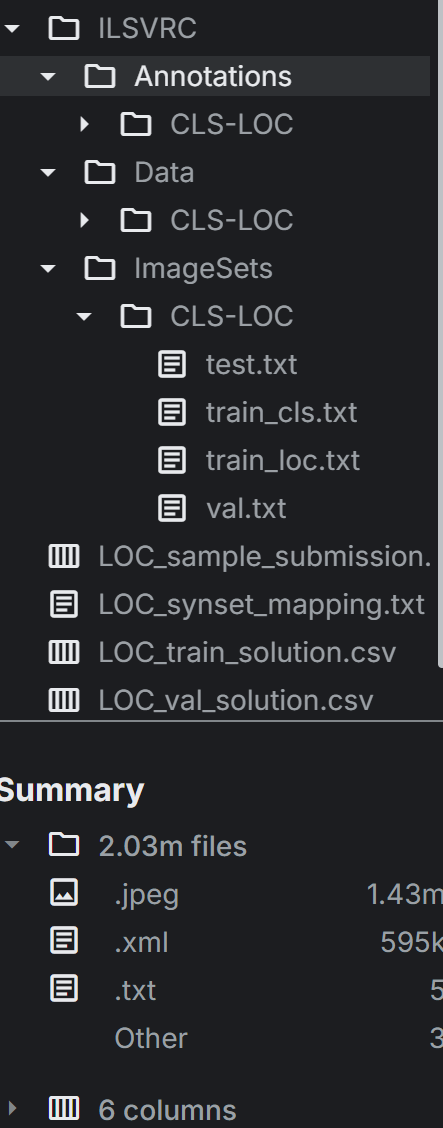

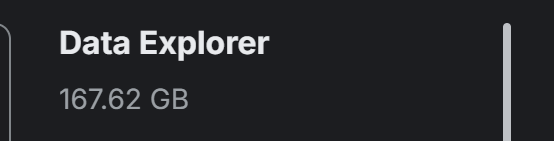

## Análisis Exploratorio de Datos de Rostros - entregado en leccion anterior

    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17
Número de muestras: 7591
Columnas: ['file_name', 'real_age']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB
None
file_name    0
real_age     0
dtype: int64


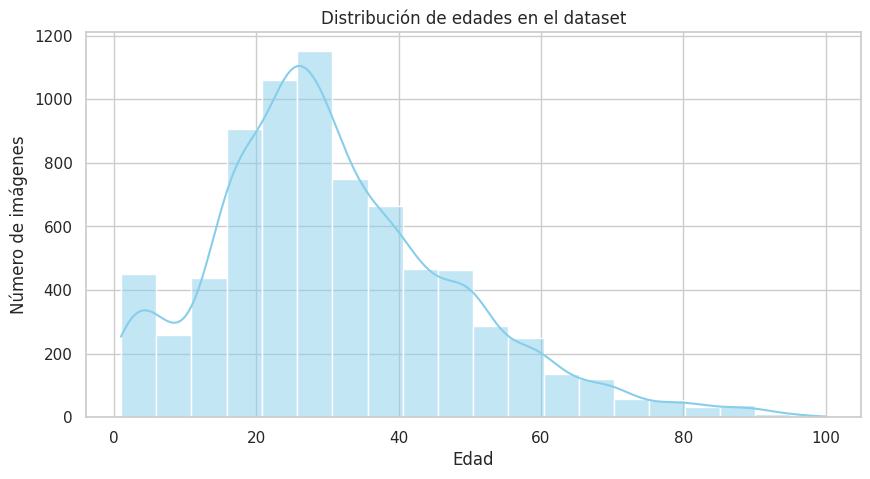

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64
No se pudo abrir la imagen /datasets/faces/final_files/005370.jpg
No se pudo abrir la imagen /datasets/faces/final_files/004516.jpg
No se pudo abrir la imagen /datasets/faces/final_files/003968.jpg
No se pudo abrir la imagen /datasets/faces/final_files/002188.jpg
No se pudo abrir la imagen /datasets/faces/final_files/005833.jpg
No se pudo abrir la imagen /datasets/faces/final_files/005521.jpg
No se pudo abrir la imagen /datasets/faces/final_files/005393.jpg
No se pudo abrir la imagen /datasets/faces/final_files/003913.jpg
No se pudo abrir la imagen /datasets/faces/final_files/000934.jpg
No se pudo abrir la imagen /datasets/faces/final_files/006264.jpg
No se pudo abrir la imagen /datasets/faces/final_files/003411.jpg
No se pudo abrir la imagen /datasets/faces/final_files/001889.jpg
No se pud

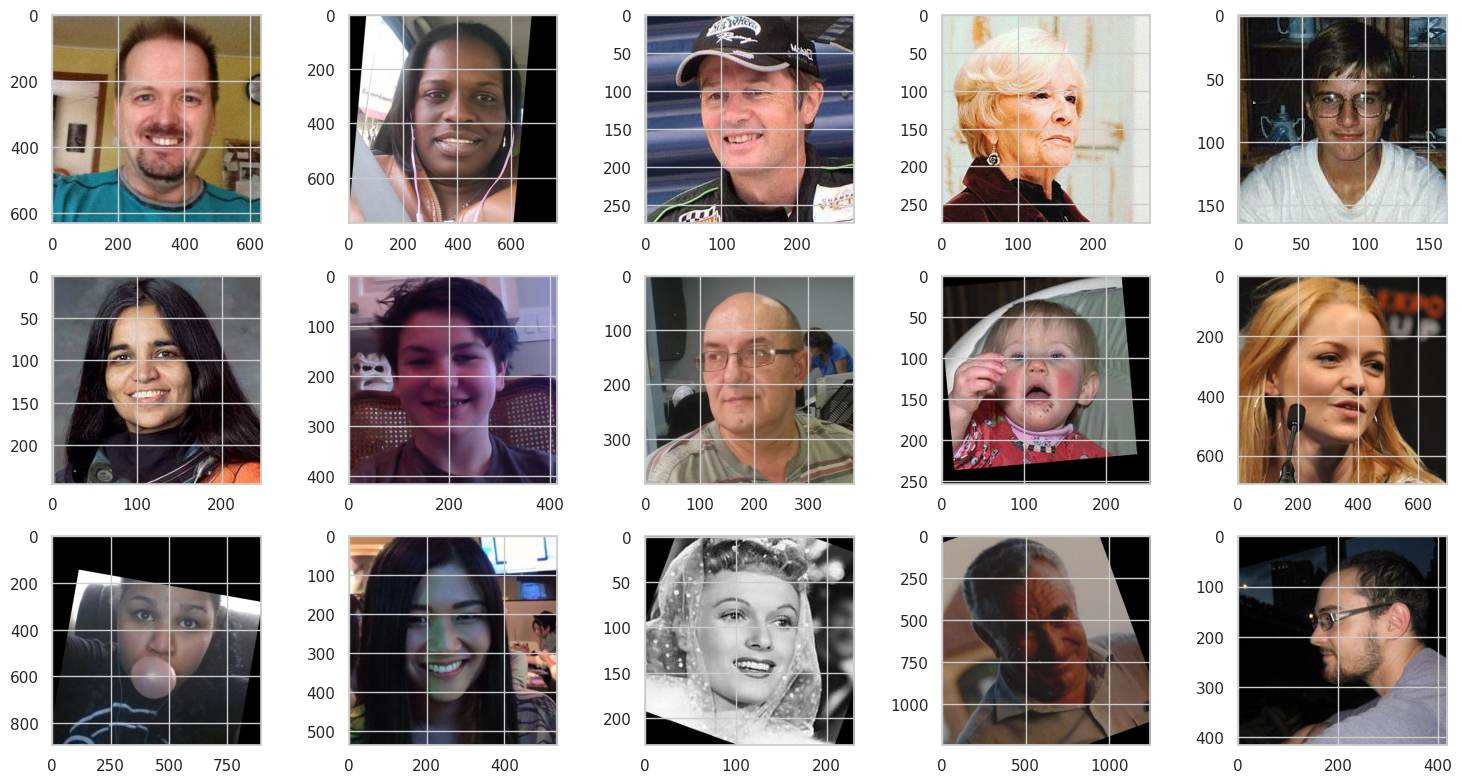

In [8]:
# Librerías para manejo de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

# Configuración de estilo
sns.set(style="whitegrid") 
%matplotlib inline 

#Cargar etiquetas y explorar el dataset
labels_path = '/datasets/faces/labels.csv'

# Cargar datos
labels_df = pd.read_csv(labels_path)

# Ver primeras filas
print(labels_df.head())

# Revisar tamaño del dataset
print("Número de muestras:", len(labels_df))

# Revisar columnas disponibles
print("Columnas:", labels_df.columns.tolist())

# Tipos de datos y valores nulos
print(labels_df.info())
print(labels_df.isnull().sum())

# Histograma de edades
plt.figure(figsize=(10,5))
sns.histplot(labels_df['real_age'], bins=20, kde=True, color='skyblue')
plt.title("Distribución de edades en el dataset")
plt.xlabel("Edad")
plt.ylabel("Número de imágenes")
plt.show()

# Resumen estadístico
print(labels_df['real_age'].describe())

#Visualizar algunas imágenes por edad
images_path = Path('/datasets/faces/final_files/')

# Seleccionar 10-15 imágenes al azar o por edad específica
sample_df = labels_df.sample(15, random_state=12345)  # 15 imágenes aleatorias
plt.figure(figsize=(15,8))
for i, row in enumerate(sample_df.itertuples()):
    img_file = images_path / row.file_name
    try:
        img = Image.open(img_file)
        plt.subplot(3, 5, i+1)
        plt.imshow(img)
        plt.title(f"Edad: {row.age}")
        plt.axis('off')
    except:
        print(f"No se pudo abrir la imagen {img_file}")
plt.tight_layout()
plt.show()

##  Codigo simulado para la creacion de la red neuronal


In [ ]:
#Librerias
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

#carga los conjuntos de datos de entrenamiento y prueba
def load_data(path, subset=None):
    labels = pd.read_csv(path + 'labels.csv')
    
    if subset:
        data_datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.2
        )
    else:
        data_datagen = ImageDataGenerator(rescale=1./255)

    data_gen_flow = data_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset=subset,
        seed=12345)

    return data_gen_flow

# define un modelo
def create_model(input_shape):
    
    backbone = ResNet50(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False
    )
    
    backbone.trainable = False  #sino estaria entrenando toda la red y seria muy lento

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5)) #para prevenir el overfitting, apaga aleatoriamente el 50% de las neuronas
    model.add(Dense(1))  #mejor para regresion, relu limita valores negativos (aunque edad no lo es, puede afectar gradientes)

    optimizer = Adam(learning_rate=0.0005)
    
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

#controla el entrenamiento del modelo   
def train_model(model, train_data, val_data, epochs=10):

    model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        verbose=2
    )

    return model


input_shape = (224, 224, 3)

train = load_data('/datasets/train/', subset='training')
val = load_data('/datasets/train/', subset='validation')
test = load_data('/datasets/test/')

model = create_model(input_shape)
model = train_model(model, train, val)

# evaluación final
model.evaluate(test)

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class="tocSkip"></a>

Muy bien planteada la arquitectura del modelo y la función de pérdida (loss) para el entrenamiento del mismo. Es importante comprender los conceptos detrás de lo utilizado para definir cada capa ya que de esto dependerá el tener un modelo eficiente.


## Conclusiones

lamento no haber podido completar este proyecto como se debia, intente realizar al menos el codigo y entender la estrctura, pero no pude procesarlo

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteración)</b> <a class="tocSkip"></a>

Muy buen trabajo con el avance del proyecto Carolina! Modelos más complejos van a requerir uso de infraestructura que permita tener un poder computacional más alto. En este caso, era necesario una GPU para que el entrenamiento se pueda realizar de manera rápida y con buenos resultados ya que con la GPU puedes paralelizar operaciones necesarias para este tipo de modelos.

Pero, debido a que esto puede ser una limitante, la parte del GPU es opcional y tu proyecto se revisa el EDA y la arquitectura del modelo planteada lo cual cumpliste muy bien y se puede aprobar. Pero, si tienes curiosidad para probar este tipo de modelos te recomiendo explorar Google Colab que te de un entorno con GPU de manera gratuita con tu cuenta de `gmail`.

Cómo puedes ver el poder computacional disponible es importante, por lo que siempre hay que saber que tipo de modelo es mejor para cada tarea y escoger lo que más beneficio y óptimo sea para una solución adecuada cómo en este caso sobre vision por computador lo mejor es utilizar redes neuronales pero está la otra parte de la infraestructura necesaria para el modelo.

Saludos!

# Lista de control

- [ ]  El Notebook estaba abierto 
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución
- [ ]  Se realizó el análisis exploratorio de datos 
- [ ]  Los resultados del análisis exploratorio de datos se presentan en el notebook final 
- [ ]  El valor EAM del modelo no es superior a 8 
- [ ]  El código de entrenamiento del modelo se copió en el notebook final 
- [ ]  El resultado de entrenamiento del modelo se copió en el notebook final 
- [ ] Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo